In [89]:
from copula_apply_utils import *
import numpy as np
from scipy.stats import t, norm
from copulae.elliptical import GaussianCopula
from copulae.elliptical import StudentCopula
import yfinance as yf
import matplotlib.pyplot as plt
import ruptures as rpt
import pandas as pd

### Getting Market Data (Market Data Dates: 1/1/2015 to 1/1/2024)

In [90]:
# Risk Free Rate (SOFR)
sofr_rate = pd.read_excel("sofr_historical.xlsx")
sofr_rate['Date'] = pd.to_datetime(sofr_rate["Effective Date"])
sofr_rate_series = sofr_rate.set_index("Date")["Rate (%)"] / 100

one_month_rate = pd.read_csv("one_month_yield_treasury_historical.csv")
one_month_rate["Date"] = pd.to_datetime(one_month_rate["observation_date"])
one_month_rate_series = one_month_rate.set_index("Date")["DGS1MO"]
one_month_rate_series = one_month_rate_series.interpolate(method="cubicspline") / 100

/Users/willneuner/Desktop/FINTECH545/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [91]:
# one_month_rate_series[((one_month_rate_series.isna() + one_month_rate_series.isna().shift(1)) == 2)]
# one_month_rate_series.loc["2001-09-12"]
# plt.subplot(121)
# plt.plot(one_month_rate_series)
# plt.subplot(122)
# plt.plot(one_month_rate_series.interpolate(method="cubicspline"))

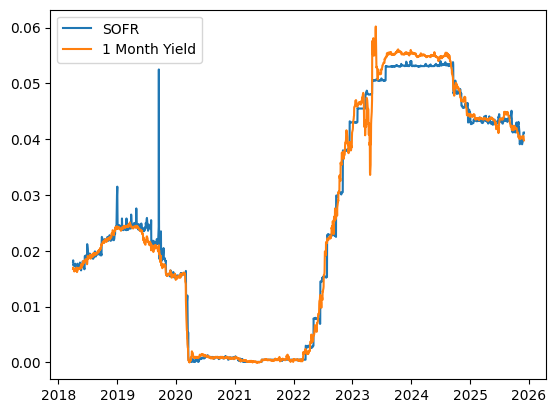

In [92]:
plt.plot(sofr_rate_series, label="SOFR")
plt.plot(one_month_rate_series[sofr_rate_series.index], label="1 Month Yield")
plt.legend()

In [93]:
start_date = "2015-01-01"
end_date = "2024-01-01"
tickers = list(yahoo_tickers.values())
price_data, returns = get_yfinance_data(tickers, start=start_date, end=end_date, interval="1d")
returns_np = returns.to_numpy()

[*********************100%***********************]  19 of 19 completed


In [94]:
spy_data, spy_returns = get_yfinance_data(["SPY"], start=start_date, end=end_date, interval="1d")
spy_returns_np = spy_returns.to_numpy()

[*********************100%***********************]  1 of 1 completed


### Breakpoint Finding

#### With data in hand, we now need to decide when the drops occur, while we could do this manually, I prefer to leave discretion at the door and do it with a breakpoint algorithm. Let's use SPY as a reflection of the overall market for this

In [95]:
pred_bkpts, penalty = get_breakpoints(spy_returns_np, n_pts=10, model="normal", min_penalty = 10, max_penalty = 1000, tolerance=0, verbose=True)

/Users/willneuner/Desktop/FINTECH545/.venv/lib/python3.12/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


Trying Pen 505
Num bkpts 0
Trying Pen 257
Num bkpts 2
Trying Pen 133
Num bkpts 2
Trying Pen 71
Num bkpts 4
Trying Pen 40
Num bkpts 10


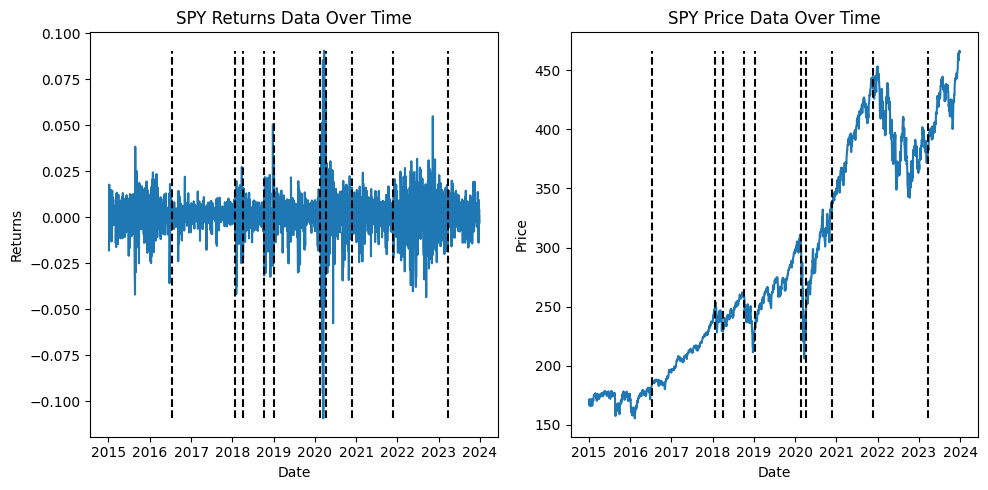

In [162]:
# fig, ax = plt.subplots(figsize=(8, 5), nrows=1, ncols=2)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plot_breakpoints(spy_returns["SPY"], pred_bkpts)
plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("SPY Returns Data Over Time")
# plt.figure(figsize=(14, 5))
plt.subplot(122)
plot_breakpoints(spy_data["SPY"], pred_bkpts)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("SPY Price Data Over Time")
plt.tight_layout()
plt.show()

In [97]:
spy_data.index[pred_bkpts]

DatetimeIndex(['2016-07-14', '2018-01-24', '2018-04-06', '2018-10-03',
               '2019-01-08', '2020-02-19', '2020-04-08', '2020-11-24',
               '2021-11-22', '2023-03-24'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [98]:
crash_start_day = "2020-02-19"
crash_start_day_2 = "2021-11-22"

### Now that we have the crash days, we need to fit our copulas to create a good portfolio up to that point

#### GLOBAL DATA TO BE USED IN BOTH BRANCHES

In [99]:
# Data from the testing period
fitting_end = "2020-01-01"
fitting_data = price_data.loc[start_date:fitting_end]
fitting_returns = returns.loc[start_date:fitting_end]
fitting_returns_np = fitting_returns.to_numpy()

# simulation
n_sims = 100_000
scale = 252 # turn daily returns into yearly

# portfolio fitting
portfolio_start_date = '2019-12-31'
rfr = one_month_rate_series[portfolio_start_date]
prices = price_data.loc[portfolio_start_date].to_numpy()
portfolio_value = 1
w0 = np.ones(shape=(prices.shape[0]))/prices.shape[0]
holdings = portfolio_value * w0 / prices

weight_bounds = (0, 1)
alpha = 0.05

# Real data stress testing
stress_test_start = "2020-01-01"
stress_test_end = "2020-4-01"
test_returns = returns.loc[stress_test_start:stress_test_end]
# cum_test_returns = (1+test_returns).cumprod()-1
test_returns_np = test_returns.to_numpy()
# cum_test_returns_np = np.cumprod((1+test_returns_np), axis=0)-1
test_prices = price_data.loc[stress_test_start:stress_test_end]

### Performing our work with a normal distribution fit on our returns

In [100]:
# normal distribution specific variables
# dist = "norm"

In [101]:
U_norm, norm_params = transform_data_to_uniform(fitting_returns_np, dist="norm")

In [102]:
# FITTING OUR COPULAS TO NORMAL DISTRIBUTION RETURN DATA

# fit a gaussian copula
norm_copula_n_data = GaussianCopula(dim=len(fitting_data.columns))
norm_copula_n_data.fit(U_norm, to_pobs=False, method="ml", verbose=10)

# fit a t copula
t_copula_n_data = StudentCopula(dim=len(fitting_data.columns))
t_copula_n_data.fit(U_norm, to_pobs=False, method="ml", verbose=10)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -10281.901752459187
            Iterations: 187
            Function evaluations: 32713
            Gradient evaluations: 187
Optimization terminated successfully    (Exit mode 0)
            Current function value: -10551.839365964704
            Iterations: 205
            Function evaluations: 36040
            Gradient evaluations: 205


In [150]:

pd.DataFrame(norm_copula_n_data.sigma - t_copula_n_data.sigma, index=price_data.columns, columns= price_data.columns).style.format("{:.3f}")

Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,,,,,,
DBA,0.000,0.014,0.011,-0.009,-0.015,-0.001,0.004,0.015,-0.012,0.001,-0.001,0.006,-0.001,-0.001,-0.000,-0.003,-0.005,-0.002,0.000
DBC,0.014,0.000,0.003,-0.003,-0.009,-0.001,-0.002,-0.002,-0.004,-0.011,-0.014,-0.003,-0.007,-0.009,-0.013,-0.013,-0.002,-0.011,-0.013
FXE,0.011,0.003,0.000,-0.043,-0.066,-0.016,0.011,0.008,0.001,-0.006,0.016,0.006,0.017,0.018,0.011,-0.005,-0.016,0.001,0.012
FXY,-0.009,-0.003,-0.043,0.000,-0.016,-0.011,-0.005,0.002,0.045,0.002,0.000,0.005,-0.006,-0.001,0.005,-0.003,-0.002,-0.003,-0.002
GLD,-0.015,-0.009,-0.066,-0.016,0.000,-0.013,-0.017,-0.010,0.069,-0.001,-0.008,-0.003,-0.011,-0.007,0.002,-0.005,-0.008,-0.006,-0.009
RWR,-0.001,-0.001,-0.016,-0.011,-0.013,0.000,0.005,0.002,0.016,-0.014,-0.016,-0.004,-0.011,-0.012,-0.012,-0.003,-0.006,-0.009,-0.008
UNG,0.004,-0.002,0.011,-0.005,-0.017,0.005,0.000,0.003,-0.014,-0.007,-0.003,-0.007,-0.001,-0.001,-0.013,-0.002,-0.002,-0.004,-0.003
USO,0.015,-0.002,0.008,0.002,-0.010,0.002,0.003,0.000,-0.009,-0.012,-0.014,-0.005,-0.009,-0.011,-0.016,-0.013,-0.000,-0.012,-0.012
UUP,-0.012,-0.004,0.001,0.045,0.069,0.016,-0.014,-0.009,0.000,0.002,-0.019,-0.008,-0.019,-0.021,-0.012,0.004,0.016,-0.003,-0.014


In [103]:
t_copula_n_data.params.df

np.float64(35.03430359265785)

#### Simulating results to evaluate risk

In [104]:
sim_t_cop_year_returns = simulate_time_scaled_returns(t_copula_n_data, t_copula_n_data.dim, norm_params, n_sims, scale, dist="norm")
sim_norm_cop_year_returns = simulate_time_scaled_returns(norm_copula_n_data, norm_copula_n_data.dim, norm_params, n_sims, scale, dist="norm")

In [105]:
# printing out the baseline ES and VAR for an equal weight portfolio 
portfolio_norm_cop_returns = compute_portfolio_returns(sim_norm_cop_year_returns, prices, holdings)
VaR_pct_n, ES_pct_n = compute_var_es(portfolio_norm_cop_returns, alpha=alpha)
print("Norm copula risk", VaR_pct_n, ES_pct_n)
portfolio_t_cop_returns = compute_portfolio_returns(sim_t_cop_year_returns, prices, holdings)
VaR_pct_t, ES_pct_t = compute_var_es(portfolio_t_cop_returns, alpha=alpha)
VaR_pct_t, ES_pct_t
print("t copula risk", VaR_pct_t, ES_pct_t)

Norm copula risk 0.09457333819474582 0.12455195024528953
t copula risk 0.09685287356011403 0.1276272258075712


In [106]:
# computing ES sharpe optimal portfolios
mean_norm_returns = get_mean_returns(norm_params, scale=scale)
norm_vols = get_vols(norm_params, scale=scale)
w_norm_n = compute_optimal_es_sharpe_weights(mean_norm_returns, prices, rfr, sim_norm_cop_year_returns, alpha = alpha, weight_bounds = weight_bounds)
w_t_n = compute_optimal_es_sharpe_weights(mean_norm_returns, prices, rfr, sim_t_cop_year_returns, alpha = alpha, weight_bounds = weight_bounds)

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: -2.6923484283779002
            Iterations: 117
            Function evaluations: 2819
            Gradient evaluations: 113
Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: -2.9643688476294945
            Iterations: 109
            Function evaluations: 2616
            Gradient evaluations: 105


In [107]:
pd.DataFrame(data=[mean_norm_returns, norm_vols, w_norm_n, w_t_n], index=["mean return", "vol", "norm copula", "t_copula"],  columns=price_data.columns)

Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
mean return,-6.814062e-02,-9.161918e-03,-0.017775,0.019798,0.053039,6.776250e-02,-1.735397e-01,-2.785132e-02,0.022942,6.014808e-02,8.061799e-02,2.805355e-03,0.118835,1.054146e-01,0.191221,8.700020e-02,0.105570,1.072120e-01,0.137618
vol,1.118418e-01,1.539272e-01,0.083646,0.087168,0.125609,1.501989e-01,4.008775e-01,3.476078e-01,0.070456,1.584095e-01,1.661301e-01,2.124671e-01,0.170410,1.525459e-01,0.174700,1.193570e-01,0.140906,1.500844e-01,0.149033
norm copula,7.396669e-15,9.971231e-15,0.206747,0.156531,0.058747,8.820532e-15,2.623538e-15,1.461045e-13,0.421316,1.751916e-15,8.887583e-15,8.404524e-15,0.034229,7.808633e-12,0.082789,1.341113e-11,0.039026,9.491391e-12,0.000616
t_copula,6.914693e-16,2.295973e-16,0.220446,0.149162,0.057197,1.060245e-16,1.737739e-15,6.176010e-16,0.439199,4.958741e-16,1.861090e-16,9.522269e-16,0.025786,3.173220e-13,0.073105,5.889989e-13,0.033274,4.458341e-13,0.001831


In [108]:
# Display optimal VaR and ES for our optimal portfolios
holdings_norm_n = portfolio_value * w_norm_n / prices
portfolio_norm_cop_returns = compute_portfolio_returns(sim_norm_cop_year_returns, prices, holdings_norm_n)
VaR_pct_n, ES_pct_n = compute_var_es(portfolio_norm_cop_returns, alpha=0.05)
print("Norm copula risk", VaR_pct_n, ES_pct_n)
holdings_t_n = portfolio_value * w_t_n / prices
portfolio_t_cop_returns = compute_portfolio_returns(sim_t_cop_year_returns, prices, holdings_t_n)
VaR_pct_t, ES_pct_t = compute_var_es(portfolio_t_cop_returns, alpha=0.05)
print("t copula risk", VaR_pct_t, ES_pct_t)

Norm copula risk -0.0004055527510429297 0.007989022098654352
t copula risk -0.0012807848923563727 0.006123668770566515


#### We have decided portfolio weights for our two portfolios, we now need to see what would happen in the real world

In [109]:
t_cop_portfolio_value = test_prices.dot(holdings_t_n)
norm_cop_portfolio_value = test_prices.dot(holdings_norm_n)
norm_drawdown, _ = compute_max_drawdown(norm_cop_portfolio_value)
t_drawdown, _ = compute_max_drawdown(t_cop_portfolio_value)
norm_drawdown, t_drawdown

(np.float64(-0.04610201767249857), np.float64(-0.03881440049009026))

In [110]:
t_port_ave_ret, t_port_vol = (t_cop_portfolio_value.pct_change().dropna()).mean(), (t_cop_portfolio_value.pct_change().dropna()).std()
norm_port_ave_ret, norm_port_vol = (norm_cop_portfolio_value.pct_change().dropna()).mean(), (norm_cop_portfolio_value.pct_change().dropna()).std()
t_port_ave_ret, t_port_vol, norm_port_ave_ret, norm_port_vol

(np.float64(-0.00020881335122270448),
 np.float64(0.00565151251538459),
 np.float64(-0.00029891977010159683),
 np.float64(0.0062795435121070844))

In [111]:
# SHARPE RATIOS
daily_rfr = rfr/scale
((t_port_ave_ret - daily_rfr) / t_port_vol)*np.sqrt(scale), ((norm_port_ave_ret - daily_rfr) / norm_port_vol)*np.sqrt(scale)

(np.float64(-0.751501751395952), np.float64(-0.904128874607889))

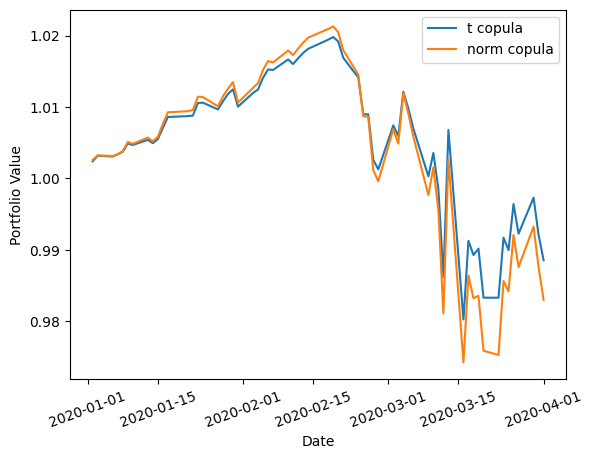

In [112]:
plt.plot(t_cop_portfolio_value, label="t copula")
plt.plot(norm_cop_portfolio_value, label="norm copula")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=20)
plt.legend()

#### Let's see how likely these returns were

In [113]:
test_returns_np.shape

(63, 19)

In [114]:
norm_params

{0: {'loc': np.float64(-0.00027039929548486254),
  'scale': np.float64(0.00704537310278928)},
 1: {'loc': np.float64(-3.635681742108416e-05),
  'scale': np.float64(0.009696504228915612)},
 2: {'loc': np.float64(-7.053656487527877e-05),
  'scale': np.float64(0.005269218849438009)},
 3: {'loc': np.float64(7.856456078199598e-05),
  'scale': np.float64(0.00549107776329956)},
 4: {'loc': np.float64(0.00021047269068504026),
  'scale': np.float64(0.007912653651998882)},
 5: {'loc': np.float64(0.0002688987922485848),
  'scale': np.float64(0.009461640396344223)},
 6: {'loc': np.float64(-0.000688649612193128),
  'scale': np.float64(0.02525291127714757)},
 7: {'loc': np.float64(-0.00011052110655418578),
  'scale': np.float64(0.021897232971465633)},
 8: {'loc': np.float64(9.104073519201367e-05),
  'scale': np.float64(0.004438305692649566)},
 9: {'loc': np.float64(0.0002386828455260061),
  'scale': np.float64(0.009978859453125242)},
 10: {'loc': np.float64(0.00031991264251480736),
  'scale': np.flo

In [144]:
dummy_returns = np.array([mean_norm_returns/scale]*test_returns_np.shape[0])

# dummy_U, _ = transform_data_to_uniform(dummy_returns, dist="norm", rv_params=norm_params)
dummy_U = np.ones(shape=test_returns.shape)/2
t_LL = t_copula_n_data.log_lik(dummy_U, to_pobs=False)
norm_LL = norm_copula_n_data.log_lik(dummy_U, to_pobs=False)

print("LLs", t_LL, norm_LL)

LLs 664.4387301443056 515.321939441217


In [116]:
t_copula_n_data.pdf(dummy_U[0,:])

38049.62509280885

In [117]:
dummy_U

array([[0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       ...,
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5]], shape=(63, 19))

In [118]:
# Convert the real world returns into uniform
real_data_U_norm, _ = transform_data_to_uniform(test_returns_np, dist="norm", rv_params=norm_params)

In [119]:
clipped_real_data_U_norm = np.clip(real_data_U_norm, a_min = 1e-16, a_max=1-1e-16)
t_LL = t_copula_n_data.log_lik(clipped_real_data_U_norm, to_pobs=False)
norm_LL = norm_copula_n_data.log_lik(clipped_real_data_U_norm, to_pobs=False)

print("LLs", t_LL, norm_LL)

LLs 3546.508759986215 1816.277951926447


In [120]:
tail_dep_df = pd.DataFrame(compute_tail_dependence(t_copula_n_data.params.df, t_copula_n_data.sigma), index=price_data.columns, columns = price_data.columns)

# Format floats to two decimal places
def color_greater_than_thresh(val, thresh):
    """
    Takes a scalar value and returns a CSS style string.
    """
    color = 'red' if (val > thresh and val != 1) else 'white'
    return f'color: {color}'
styled_df = tail_dep_df.style.applymap(lambda x: color_greater_than_thresh(x, 0.01))

# Print the result
styled_df.format('{:.3f}')

/var/folders/1d/dkqlxg7d3yv8ccfw3vkrtnsm0000gn/T/ipykernel_71956/97749323.py:10: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = tail_dep_df.style.applymap(lambda x: color_greater_than_thresh(x, 0.01))


Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,,,,,,
DBA,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
DBC,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.178,0.000,0.000,0.001,0.015,0.000,0.000,0.000,0.000,0.000,0.000,0.000
FXE,0.000,0.000,1.000,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
FXY,0.000,0.000,0.001,1.000,0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
GLD,0.000,0.000,0.001,0.003,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
RWR,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.001,0.001,0.007,0.006,0.001,0.002
UNG,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
USO,0.000,0.178,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.000
UUP,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


### Performing our work with a t distribution fit on our returns

In [121]:
# Get Uniform data for Gaussian and for T
U_t, t_params = transform_data_to_uniform(fitting_returns_np, dist="t")

In [157]:
np.mean([t_param['df'] for _, t_param in t_params.items()])

np.float64(5.14253062260645)

In [160]:
[(t_params[key]['loc']-norm_params[key]['loc'])*scale for key, t_param in t_params.items()]

[np.float64(-0.009334616681922156),
 np.float64(0.013303526614139086),
 np.float64(-0.004592744623986716),
 np.float64(-0.0443745501717644),
 np.float64(-0.021308051681240066),
 np.float64(0.10470227817223028),
 np.float64(-0.09795262166481714),
 np.float64(0.043625733332603375),
 np.float64(-0.048674972548326784),
 np.float64(0.04138222726703546),
 np.float64(0.0532564955577261),
 np.float64(0.01890182774554182),
 np.float64(0.06507764755733952),
 np.float64(0.10022842572144863),
 np.float64(0.12476980978732345),
 np.float64(0.06227927505235579),
 np.float64(0.11032095501898302),
 np.float64(0.09743264720796252),
 np.float64(0.10528393479791356)]

In [161]:
[(t_params[key]['scale']-norm_params[key]['scale'])*np.sqrt(scale) for key, t_param in t_params.items()]

[np.float64(-0.007821920237115997),
 np.float64(-0.023154260042970606),
 np.float64(-0.0178452819242315),
 np.float64(-0.023207007702922423),
 np.float64(-0.026335387637513728),
 np.float64(-0.028655696607996023),
 np.float64(-0.10181185774108573),
 np.float64(-0.07190423768039013),
 np.float64(-0.023829134638567975),
 np.float64(-0.030820551596446404),
 np.float64(-0.033752814182906654),
 np.float64(-0.045928767282234106),
 np.float64(-0.04688308578685678),
 np.float64(-0.042927255452045066),
 np.float64(-0.06274769415296103),
 np.float64(-0.026756352271214184),
 np.float64(-0.02887106346856455),
 np.float64(-0.03867616401332105),
 np.float64(-0.04518147121746256)]

In [122]:
# FITTING OUR COPULAS TO T DISTRIBUTION RETURN DATA
# fit a gaussian copula
norm_copula_t_data = GaussianCopula(dim=len(fitting_data.columns))
norm_copula_t_data.fit(U_t, to_pobs=False, method="ml", verbose=10)

# fit a t copula
t_copula_t_data = StudentCopula(dim=len(fitting_data.columns))
t_copula_t_data.fit(U_t, to_pobs=False, method="ml", verbose=10)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -9632.611129194542
            Iterations: 184
            Function evaluations: 32221
            Gradient evaluations: 184
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9919.020265297035
            Iterations: 191
            Function evaluations: 33606
            Gradient evaluations: 191


In [123]:
t_copula_t_data.params.df

np.float64(13.679383821588686)

In [153]:
pd.DataFrame(t_copula_t_data.sigma, index=price_data.columns, columns= price_data.columns).style.format("{:.3f}")

Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,,,,,,
DBA,1.000,0.388,0.170,0.032,0.103,0.103,0.084,0.203,-0.182,0.167,0.220,0.197,0.154,0.180,0.161,0.134,0.045,0.108,0.202
DBC,0.388,1.000,0.184,-0.021,0.192,0.106,0.214,0.898,-0.218,0.287,0.416,0.687,0.281,0.329,0.279,0.168,0.042,0.194,0.283
FXE,0.170,0.184,1.000,0.501,0.486,0.027,0.042,0.102,-0.954,0.019,0.065,0.061,-0.083,-0.022,-0.038,0.048,0.083,-0.012,-0.031
FXY,0.032,-0.021,0.501,1.000,0.585,-0.055,-0.005,-0.080,-0.595,-0.221,-0.261,-0.225,-0.436,-0.337,-0.315,-0.144,0.059,-0.252,-0.311
GLD,0.103,0.192,0.486,0.585,1.000,0.068,0.026,0.059,-0.547,-0.017,-0.014,-0.018,-0.255,-0.130,-0.114,-0.012,0.138,-0.083,-0.128
RWR,0.103,0.106,0.027,-0.055,0.068,1.000,-0.001,0.097,-0.045,0.466,0.399,0.284,0.369,0.438,0.426,0.604,0.597,0.455,0.488
UNG,0.084,0.214,0.042,-0.005,0.026,-0.001,1.000,0.127,-0.034,0.037,0.040,0.139,0.027,0.029,-0.012,0.010,0.013,0.012,0.013
USO,0.203,0.898,0.102,-0.080,0.059,0.097,0.127,1.000,-0.136,0.275,0.392,0.709,0.282,0.320,0.273,0.164,0.037,0.186,0.264
UUP,-0.182,-0.218,-0.954,-0.595,-0.547,-0.045,-0.034,-0.136,1.000,-0.024,-0.080,-0.084,0.091,0.023,0.039,-0.057,-0.099,0.009,0.029


#### Simulating results to evaluate risk

In [124]:
sim_t_cop_year_returns = simulate_time_scaled_returns(t_copula_n_data, t_copula_n_data.dim, norm_params, n_sims, scale, dist="norm")
sim_norm_cop_year_returns = simulate_time_scaled_returns(norm_copula_n_data, norm_copula_n_data.dim, norm_params, n_sims, scale, dist="norm")

In [125]:
portfolio_norm_cop_returns = compute_portfolio_returns(sim_norm_cop_year_returns, prices, holdings)
VaR_pct_n, ES_pct_n = compute_var_es(portfolio_norm_cop_returns, alpha=alpha)
print("Norm copula risk", VaR_pct_n, ES_pct_n)
portfolio_t_cop_returns = compute_portfolio_returns(sim_t_cop_year_returns, prices, holdings)
VaR_pct_t, ES_pct_t = compute_var_es(portfolio_t_cop_returns, alpha=alpha)
VaR_pct_t, ES_pct_t
print("t copula risk", VaR_pct_t, ES_pct_t)

Norm copula risk 0.09492359068272534 0.12561817195189862
t copula risk 0.0968675485968816 0.1277544928928909


In [126]:
mean_t_returns = get_mean_returns(t_params, scale=scale) 
t_vols = get_vols(t_params, scale=scale)
w_norm_n = compute_optimal_es_sharpe_weights(mean_t_returns, prices, rfr, sim_norm_cop_year_returns, alpha = alpha, weight_bounds = weight_bounds)
w_t_n = compute_optimal_es_sharpe_weights(mean_t_returns, prices, rfr, sim_t_cop_year_returns, alpha = alpha, weight_bounds = weight_bounds)

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: -2.8723154028728373
            Iterations: 327
            Function evaluations: 8998
            Gradient evaluations: 323
Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: -2.871641526807099
            Iterations: 173
            Function evaluations: 4147
            Gradient evaluations: 169


In [143]:
pd.DataFrame(data=[mean_t_returns, t_vols, w_norm_n, w_t_n], index=["mean return", "vol", "norm copula", "t_copula"],  columns=price_data.columns)

Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
mean return,-7.747524e-02,4.141609e-03,-2.236796e-02,-0.024576,0.031731,1.724648e-01,-2.714923e-01,1.577441e-02,-0.025733,1.015303e-01,1.338745e-01,2.170718e-02,0.183913,2.056430e-01,0.315991,1.492795e-01,0.215891,2.046446e-01,0.242902
vol,1.040199e-01,1.307730e-01,6.580097e-02,0.063961,0.099274,1.215432e-01,2.990657e-01,2.757036e-01,0.046627,1.275889e-01,1.323773e-01,1.665383e-01,0.123527,1.096187e-01,0.111952,9.260062e-02,0.112035,1.114082e-01,0.103852
norm copula,5.472959e-16,1.963960e-16,4.018186e-16,0.214975,0.110898,3.438393e-17,1.513922e-15,7.055120e-16,0.242333,4.742524e-16,1.423097e-16,9.340053e-16,0.039766,9.193433e-13,0.229839,3.074143e-16,0.139704,3.750046e-16,0.022485
t_copula,1.722925e-15,4.824232e-16,3.997730e-13,0.211468,0.115665,6.952611e-14,5.304002e-15,1.715179e-15,0.268457,3.334421e-15,4.303459e-16,2.533638e-15,0.012615,2.532683e-13,0.231713,2.931650e-13,0.130109,1.477119e-13,0.029973


In [128]:
# see what the optimal weights var and ES are
holdings_norm_n = portfolio_value * w_norm_n / prices
portfolio_norm_cop_returns = compute_portfolio_returns(sim_norm_cop_year_returns, prices, holdings_norm_n)
VaR_pct_n, ES_pct_n = compute_var_es(portfolio_norm_cop_returns, alpha=0.05)
print("Norm copula risk", VaR_pct_n, ES_pct_n)
holdings_t_n = portfolio_value * w_t_n / prices
portfolio_t_cop_returns = compute_portfolio_returns(sim_t_cop_year_returns, prices, holdings_t_n)
VaR_pct_t, ES_pct_t = compute_var_es(portfolio_t_cop_returns, alpha=0.05)
print("t copula risk", VaR_pct_t, ES_pct_t)

Norm copula risk 0.010999123838067466 0.03229541058926465
t copula risk 0.01004508291718645 0.030531050107840126


#### We have decided portfolio weights for our two portfolios, we now need to see what would happen in the real world

In [129]:
t_cop_portfolio_value = test_prices.dot(holdings_t_n)
norm_cop_portfolio_value = test_prices.dot(holdings_norm_n)
norm_drawdown, _ = compute_max_drawdown(norm_cop_portfolio_value)
t_drawdown, _ = compute_max_drawdown(t_cop_portfolio_value)
norm_drawdown, t_drawdown

(np.float64(-0.14625400179838074), np.float64(-0.1337699367825054))

In [130]:
t_port_ave_ret, t_port_vol = (t_cop_portfolio_value.pct_change().dropna()).mean(), (t_cop_portfolio_value.pct_change().dropna()).std()
norm_port_ave_ret, norm_port_vol = (norm_cop_portfolio_value.pct_change().dropna()).mean(), (norm_cop_portfolio_value.pct_change().dropna()).std()
t_port_ave_ret, t_port_vol, norm_port_ave_ret, norm_port_vol

(np.float64(-0.0008877476012867924),
 np.float64(0.014528063766768616),
 np.float64(-0.0010543509245834971),
 np.float64(0.015422248608023027))

In [131]:
daily_rfr = rfr/scale
((t_port_ave_ret - daily_rfr) / t_port_vol)*np.sqrt(scale), ((norm_port_ave_ret - daily_rfr) / norm_port_vol)*np.sqrt(scale)

(np.float64(-1.0341962210489277), np.float64(-1.1457223172889095))

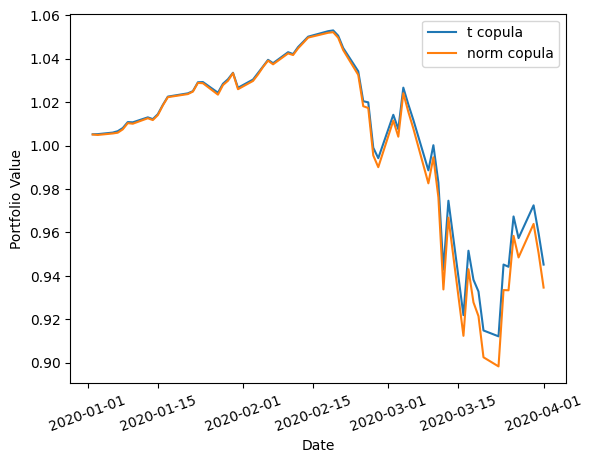

In [132]:
plt.plot(t_cop_portfolio_value, label="t copula")
plt.plot(norm_cop_portfolio_value, label="norm copula")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=20)
plt.legend()

#### Let's see how likely these returns were

In [133]:
# Convert the real world returns into uniform
real_data_U_t, _ = transform_data_to_uniform(test_returns_np, dist="t", rv_params=t_params)

In [134]:
clipped_real_data_U_t = np.clip(real_data_U_t, a_min = 1e-16, a_max=1-1e-16)
t_LL = t_copula_n_data.log_lik(clipped_real_data_U_t, to_pobs=False)
norm_LL = norm_copula_n_data.log_lik(clipped_real_data_U_t, to_pobs=False)
print("LLs", t_LL, norm_LL)

LLs 1398.8801708763422 1117.6048164453134


In [154]:
dummy_returns = np.array([mean_t_returns/scale]*test_returns_np.shape[0])

# dummy_U, _ = transform_data_to_uniform(dummy_returns, dist="t", rv_params=t_params)
dummy_U = np.ones(shape=test_returns.shape)/2
t_LL = t_copula_t_data.log_lik(dummy_U, to_pobs=False)
norm_LL = norm_copula_t_data.log_lik(dummy_U, to_pobs=False)

print("LLs", t_LL, norm_LL)

LLs 785.1455057044351 488.3873920077598


In [136]:
tail_dep_df = pd.DataFrame(compute_tail_dependence(t_copula_t_data.params.df, t_copula_t_data.sigma), index=price_data.columns, columns = price_data.columns)

# Format floats to two decimal places
def color_greater_than_thresh(val, thresh):
    """
    Takes a scalar value and returns a CSS style string.
    """
    color = 'red' if (val > thresh and val != 1) else 'white'
    return f'color: {color}'
styled_df = tail_dep_df.style.applymap(lambda x: color_greater_than_thresh(x, 0.01))

# Print the result
styled_df.format('{:.3f}')

/var/folders/1d/dkqlxg7d3yv8ccfw3vkrtnsm0000gn/T/ipykernel_71956/910410325.py:10: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = tail_dep_df.style.applymap(lambda x: color_greater_than_thresh(x, 0.01))


Ticker,DBA,DBC,FXE,FXY,GLD,RWR,UNG,USO,UUP,VOX,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Ticker,,,,,,,,,,,,,,,,,,,
DBA,1.000,0.023,0.006,0.002,0.004,0.004,0.003,0.007,0.000,0.006,0.008,0.007,0.005,0.006,0.005,0.005,0.002,0.004,0.007
DBC,0.023,1.000,0.006,0.001,0.007,0.004,0.008,0.390,0.000,0.012,0.027,0.120,0.012,0.016,0.012,0.006,0.002,0.007,0.012
FXE,0.006,0.006,1.000,0.043,0.040,0.002,0.002,0.004,0.000,0.002,0.003,0.003,0.001,0.001,0.001,0.002,0.003,0.002,0.001
FXY,0.002,0.001,0.043,1.000,0.069,0.001,0.002,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.003,0.000,0.000
GLD,0.004,0.007,0.040,0.069,1.000,0.003,0.002,0.003,0.000,0.001,0.002,0.001,0.000,0.001,0.001,0.002,0.005,0.001,0.001
RWR,0.004,0.004,0.002,0.001,0.003,1.000,0.002,0.003,0.001,0.036,0.024,0.012,0.020,0.030,0.028,0.077,0.074,0.034,0.040
UNG,0.003,0.008,0.002,0.002,0.002,0.002,1.000,0.004,0.001,0.002,0.002,0.005,0.002,0.002,0.002,0.002,0.002,0.002,0.002
USO,0.007,0.390,0.004,0.001,0.003,0.003,0.004,1.000,0.001,0.011,0.023,0.135,0.012,0.015,0.011,0.006,0.002,0.006,0.011
UUP,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,1.000,0.001,0.001,0.001,0.003,0.002,0.002,0.001,0.001,0.002,0.002


### Random testing

In [137]:
# THIS LL returns positive value, infinity is best value

# # NOTE-> this fails becuase values are too close to 0
# t_LL = t_copula_n_data.log_lik(real_data_U_norm, to_pobs=False)
# norm_LL = norm_copula_n_data.log_lik(real_data_U_norm, to_pobs=False)

# print("LLs", t_LL, norm_LL)
# print("Min U Values", np.min(real_data_U_norm), np.min(real_data_U_t))

In [138]:
# np.sum(np.log(t_copula_n_data.pdf(clipped_real_data_U_norm))) -> same as log_lik below

In [139]:
# test_prices['t_portfolio_value']  = t_cop_portfolio_value
# test_prices['norm_portfolio_value']  = norm_cop_portfolio_value

In [140]:
# plt.plot(test_prices.pct_change().dropna())
# for col in test_prices:
#     plt.plot(test_prices.pct_change().dropna().loc[:, col], label=col)
# plt.legend()

### With these copulas, let's also look at some of those properties we were talking about

In [141]:
## Tail dependence

(i, j), rho = get_max_corr(t_copula.sigma)
i, j, rho

NameError: name 't_copula' is not defined

In [ ]:
(i, j), rho = get_max_corr(norm_copula.sigma)
i, j, rho

(np.int64(1), np.int64(7), np.float64(0.8989948693283002))

NameError: name 'sim_U_t' is not defined

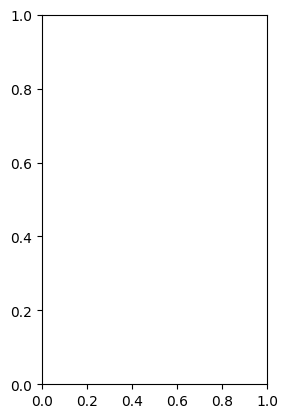

In [ ]:
plt.subplot(121)
plt.scatter(sim_U_t[:, i], sim_U_t[:, j])
plt.subplot(122)
plt.scatter(sim_U_norm[:, i], sim_U_norm[:, j])

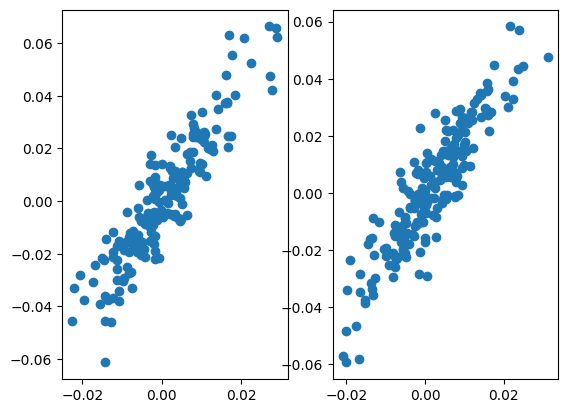

In [ ]:
plt.subplot(121)
plt.scatter(sim_t_returns[:, i], sim_t_returns[:, j])
plt.subplot(122)
plt.scatter(sim_norm_returns[:, i], sim_norm_returns[:, j])